# Model 1 — Insurance Aggregate Loss Monte Carlo
**Part 1 of 4 in *Consumption Pricing Models for Enterprise Infrastructure***

> **A note on inputs and provenance:** All inputs are illustrative, drawn from publicly available industry benchmarks. No proprietary or confidential data is used. The insurance Monte Carlo in particular is a clean-room rebuild from public actuarial methodology — not the production model from any prior role. See the README for full context.

## Why this model exists

During my internship in commercial risk advisory & risk analytics, I spent time translating Monte Carlo aggregate-loss models for client-facing analytics — but my role was to communicate the outputs, not build the engine. I wanted to revisit that domain and rebuild a model from scratch, both to reinforce my understanding of the math and to see how broadly the same probabilistic toolkit transfers to other domains.

This is the foundational rebuild. Models 2–4 apply the same toolkit to enterprise infrastructure pricing.


## Setup — Imports & Shared Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import rankdata
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
PURPLE = '#7C3AED'
TEAL   = '#0891B2'
GRAY   = '#6B7280'

def fmt_k(n):
    """Format a number as a compact dollar string."""
    if abs(n) >= 1_000_000:
        return f'${n/1_000_000:.1f}M'
    if abs(n) >= 1_000:
        return f'${n/1_000:.0f}K'
    return f'${n:.0f}'

print('Setup complete.')

Setup complete.


## What this model is

This rebuilds, from scratch, the kind of statistical engine I worked alongside in commercial risk advisory & risk analytics — where the output goes into client-facing risk dashboards. It simulates aggregate annual losses across three commercial insurance lines.

## The logic (two-step for each iteration)

**Step 1 — Frequency model (Poisson)**  
How many loss *events* happen to this client in a year?  
Poisson is the standard actuarial choice for rare, independent events. The key parameter is **λ (lambda)** = expected events per year.

**Step 2 — Severity model (Lognormal)**  
Given an event occurs, how *large* is the loss?  
Lognormal has a heavy right tail — most claims are small, occasionally one is catastrophic. This matches real insurance loss data.

**Aggregate** = sum of (n_events × severity) across all events in one iteration.  
Run 25,000 iterations → full probability distribution of possible annual loss outcomes.

## How brokers use the output
| Output | Broker use |
|---|---|
| **P50** | Expected loss — basis for premium calculation |
| **P90** | Stressed loss — informs policy limits and deductible structure |
| **P99** | Catastrophic scenario — determines reinsurance attachment point |
| **Loss exceedance curve** | Full picture for client renewal conversations |


### Assumptions

In [2]:
# ── Model 1 Assumptions ────────────────────────────────────────────────
# Three commercial insurance lines with distinct frequency/severity profiles

lines = {
    'Primary Casualty': {
        'lam': 3.5,          # Expected loss events/year (Poisson lambda)
        'sev_mean': 850_000, # Mean severity per event ($)
        'sev_cv': 1.8        # Coefficient of variation — higher = heavier tail
    },
    'Property': {
        'lam': 1.2,           # Lower frequency, much higher severity
        'sev_mean': 2_100_000,
        'sev_cv': 2.2
    },
    'Cyber': {
        'lam': 2.0,           # Elevated frequency reflecting current threat landscape
        'sev_mean': 1_400_000,
        'sev_cv': 2.5         # Highest CV — cyber losses are most unpredictable
    },
}

N_ITER  = 25_000  # iterations — enough for stable P99 convergence
RHO     = 0.25    # cross-line correlation (systemic events affect multiple lines)

print('Assumptions set.')
print(f'Lines: {list(lines.keys())}')
print(f'Iterations: {N_ITER:,}')

Assumptions set.
Lines: ['Primary Casualty', 'Property', 'Cyber']
Iterations: 25,000


### Simulation

In [3]:
def lognorm_params(mean, cv):
    """Convert (mean, CV) to lognormal (mu, sigma) parameters."""
    sigma2 = np.log(cv ** 2 + 1)
    mu = np.log(mean) - sigma2 / 2
    return mu, np.sqrt(sigma2)

# Step 1+2: Simulate frequency × severity for each line independently
line_losses = {}
for name, p in lines.items():
    mu, sigma = lognorm_params(p['sev_mean'], p['sev_cv'])
    losses = np.zeros(N_ITER)
    for i in range(N_ITER):
        n_events = np.random.poisson(p['lam'])      # How many events this year?
        if n_events > 0:
            losses[i] = np.random.lognormal(mu, sigma, n_events).sum()  # Total loss
    line_losses[name] = losses
    print(f'{name}: P50=${np.percentile(losses,50)/1e6:.1f}M  P90=${np.percentile(losses,90)/1e6:.1f}M')

# Step 3: Aggregate with cross-line correlation (Gaussian copula)
cov = np.full((3, 3), RHO)
np.fill_diagonal(cov, 1.0)
L = np.linalg.cholesky(cov)
z = np.random.randn(N_ITER, 3) @ L.T

corr_losses = np.zeros((N_ITER, 3))
for j, name in enumerate(lines):
    ranks = rankdata(z[:, j])
    sorted_line = np.sort(line_losses[name])
    indices = (ranks / (N_ITER + 1) * N_ITER).astype(int).clip(0, N_ITER - 1)
    corr_losses[:, j] = sorted_line[indices]

total_losses = corr_losses.sum(axis=1) / 1_000_000  # Convert to $M

# Key percentiles
p50 = np.percentile(total_losses, 50)
p75 = np.percentile(total_losses, 75)
p90 = np.percentile(total_losses, 90)
p99 = np.percentile(total_losses, 99)
tvar90 = total_losses[total_losses > p90].mean()

print(f'\nAggregate results across all lines:')
print(f'  P50  (expected):     ${p50:.1f}M')
print(f'  P75:                 ${p75:.1f}M')
print(f'  P90  (stressed):     ${p90:.1f}M')
print(f'  P99  (catastrophic): ${p99:.1f}M')
print(f'  TVaR above P90:      ${tvar90:.1f}M')

Primary Casualty: P50=$2.1M  P90=$6.5M


Property: P50=$0.8M  P90=$6.6M


Cyber: P50=$1.2M  P90=$6.8M

Aggregate results across all lines:
  P50  (expected):     $5.7M
  P75:                 $10.5M
  P90  (stressed):     $17.3M
  P99  (catastrophic): $42.9M
  TVaR above P90:      $28.2M


### Charts

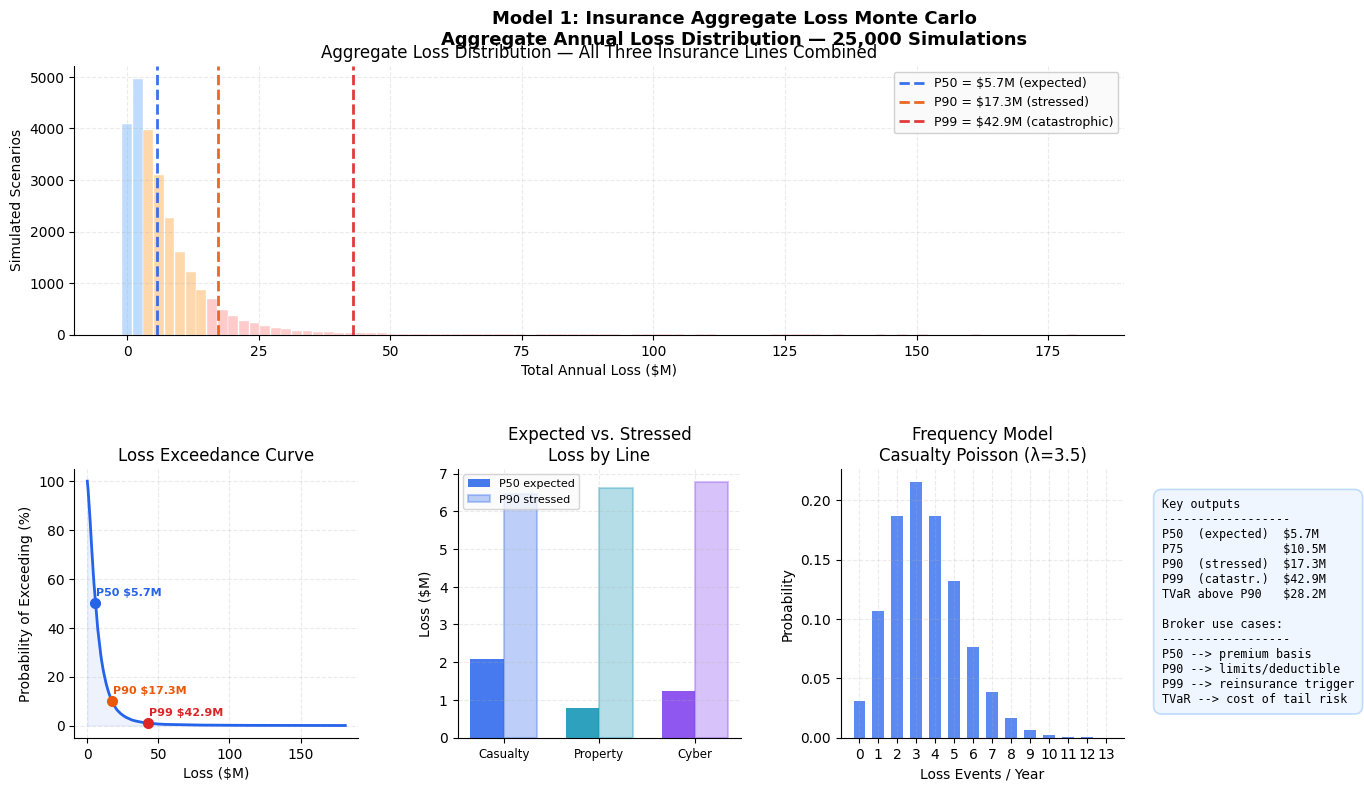

Model 1 complete.


In [4]:
fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor('white')
fig.suptitle('Model 1: Insurance Aggregate Loss Monte Carlo\nAggregate Annual Loss Distribution — 25,000 Simulations',
             fontsize=13, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 3, hspace=0.50, wspace=0.35,
                       left=0.06, right=0.76, top=0.92, bottom=0.08)

# Panel A: Aggregate loss histogram with percentile shading
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('white')
counts, edges = np.histogram(total_losses, bins=90)
for c, l, r in zip(counts, edges[:-1], edges[1:]):
    color = '#BFDBFE' if r <= p50 else ('#FED7AA' if r <= p90 else '#FECACA')
    ax1.bar(l, c, width=(r - l) * 0.93, color=color, edgecolor='white', lw=0.3)
for val, lbl, col in [(p50, f'P50 = ${p50:.1f}M (expected)', BLUE),
                       (p90, f'P90 = ${p90:.1f}M (stressed)', ORANGE),
                       (p99, f'P99 = ${p99:.1f}M (catastrophic)', '#DC2626')]:
    ax1.axvline(val, color=col, lw=2, linestyle='--', alpha=0.9, zorder=5, label=lbl)
ax1.set_xlabel('Total Annual Loss ($M)')
ax1.set_ylabel('Simulated Scenarios')
ax1.set_title('Aggregate Loss Distribution — All Three Insurance Lines Combined')
ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)

# Panel B: Loss Exceedance Probability Curve (the key broker output)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('white')
sorted_l = np.sort(total_losses)
exc = (1 - np.arange(1, N_ITER + 1) / N_ITER) * 100
ax2.plot(sorted_l, exc, color=BLUE, lw=2)
ax2.fill_between(sorted_l, exc, alpha=0.08, color=BLUE)
for pct, val, col in [(50, p50, BLUE), (90, p90, ORANGE), (99, p99, '#DC2626')]:
    ax2.plot(val, 100 - pct, 'o', color=col, ms=7, zorder=5)
    ax2.annotate(f'P{pct} ${val:.1f}M', xy=(val, 100-pct),
                 xytext=(val+0.5, 100-pct+3), fontsize=8, color=col, fontweight='bold')
ax2.set_xlabel('Loss ($M)')
ax2.set_ylabel('Probability of Exceeding (%)')
ax2.set_title('Loss Exceedance Curve')

# Panel C: Expected vs. stressed loss by line
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('white')
line_names = list(lines.keys())
lp50 = [np.percentile(line_losses[n], 50) / 1e6 for n in line_names]
lp90 = [np.percentile(line_losses[n], 90) / 1e6 for n in line_names]
x = np.arange(3)
w = 0.35
ax3.bar(x - w/2, lp50, w, label='P50 expected', color=[BLUE, TEAL, PURPLE], alpha=0.85)
ax3.bar(x + w/2, lp90, w, label='P90 stressed',
        color=[BLUE, TEAL, PURPLE], alpha=0.30, edgecolor=[BLUE, TEAL, PURPLE], lw=1.5)
ax3.set_xticks(x)
ax3.set_xticklabels(['Casualty', 'Property', 'Cyber'], fontsize=8.5)
ax3.set_ylabel('Loss ($M)')
ax3.set_title('Expected vs. Stressed\nLoss by Line')
ax3.legend(fontsize=8)

# Panel D: Frequency distribution (Poisson — conceptual explainer)
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('white')
freq_s = np.random.poisson(lines['Primary Casualty']['lam'], 10_000)
vals, cnts = np.unique(freq_s, return_counts=True)
ax4.bar(vals, cnts / cnts.sum(), color=BLUE, alpha=0.75, width=0.6)
ax4.set_xlabel('Loss Events / Year')
ax4.set_ylabel('Probability')
ax4.set_title('Frequency Model\nCasualty Poisson (λ=3.5)')
ax4.set_xticks(vals)

# Stats annotation
stats = (
    'Key outputs\n'
    '------------------\n'
    f'P50  (expected)  ${p50:.1f}M\n'
    f'P75              ${p75:.1f}M\n'
    f'P90  (stressed)  ${p90:.1f}M\n'
    f'P99  (catastr.)  ${p99:.1f}M\n'
    f'TVaR above P90   ${tvar90:.1f}M\n\n'
    'Broker use cases:\n'
    '------------------\n'
    'P50 --> premium basis\n'
    'P90 --> limits/deductible\n'
    'P99 --> reinsurance trigger\n'
    'TVaR --> cost of tail risk'
)
fig.text(0.785, 0.12, stats, fontsize=8.5, fontfamily='monospace',
         verticalalignment='bottom',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#EFF6FF', edgecolor='#BFDBFE', lw=1.2))

plt.savefig('model1_insurance_monte_carlo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Model 1 complete.')